In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
# Load and clean data
full = pd.read_csv("C:/Users/annaw/Desktop/DataScience/Datasets/full_dataset.csv", dtype={91: str})
print(f"X_train shape: {full.shape}")

# drop columns with >20% missing
full_clean = full.dropna(thresh=len(full)*0.8, axis=1)  
print(full_clean['avalancheDay1'].value_counts())

full_clean = full_clean.dropna()
full_clean = full_clean.select_dtypes(include=[np.number])
full_clean = full_clean.drop(columns=[col for col in ['year', 'datum'] if col in full_clean.columns])
print(full_clean['avalancheDay1'].value_counts())

# Split features and target
X = full_clean.drop(columns=["avalancheDay1"])
y = full_clean["avalancheDay1"]

# Single consistent split (for both RF and NN)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# RF will train on X_train_full and test on X_test
# NN will train on X_train_full (but create its own val set)

# Standardize features
scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train)
X_val_nn = scaler.transform(X_val)
X_test_nn = scaler.transform(X_test)

# Save these for SHAP use
X_background = X_train_nn[:100]
X_explain = X_test_nn

X_train shape: (11362, 95)
avalancheDay1
0    10638
1      724
Name: count, dtype: int64
avalancheDay1
0    9598
1     695
Name: count, dtype: int64


In [26]:
# Print the shapes of the datasets
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (6587, 84)
X_val shape: (1647, 84)
X_test shape: (2059, 84)
y_train shape: (6587,)
y_val shape: (1647,)
y_test shape: (2059,)


In [27]:
# Convert to PyTorch tensors

#Convert inputs
X_train_nn = torch.tensor(X_train_nn, dtype=torch.float32)
X_val_nn = torch.tensor(X_val_nn, dtype=torch.float32)
X_test_nn = torch.tensor(X_test_nn, dtype=torch.float32)

#Convert lables
y_train = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_val = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

In [40]:
# Define model
class AvalancheNet(nn.Module):
    def __init__(self, input_dim):
        super(AvalancheNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 32)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(32, 1)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

model = AvalancheNet(X_train_nn.shape[1])

# Loss and optimizer
# we use a weighted loss = model cares more about getting the avalanche days right
pos_weight = torch.tensor([5.0])  # roughly ratio of class 0 to class 1
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_nn) # Predict on training set
    loss = criterion(outputs, y_train) # Use correct training labels
    loss.backward()
    optimizer.step()
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_nn) # Predict on test set
        val_loss = criterion(val_outputs, y_test)  # Compare to test labels
    if epoch % 5 == 0:
        print(f'Epoch [{epoch}/{num_epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

# Predict
model.eval()
with torch.no_grad():
    y_pred_logits = model(X_test_nn)  # Output without sigmoid
    y_pred_probs = torch.sigmoid(y_pred_logits)  # Apply sigmoid manually

# Automatically select threshold with highest F1
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.91, 0.05)  # Test thresholds 0.1, 0.15, ..., 0.9
best_thresh = 0.5
best_f1 = 0

for thresh in thresholds:
    y_pred_thresh = (y_pred_probs > thresh).int()
    f1 = f1_score(y_test.numpy(), y_pred_thresh.numpy())
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

y_pred_nn = (y_pred_probs > best_thresh).int()  # Threshold at 0.7
print(best_thresh)

# Metrics
print("\n=== Neural Network Performance ===")
print(classification_report(y_test.numpy(), y_pred_nn.numpy()))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test.numpy(), y_pred_nn.numpy()))


Epoch [0/200], Train Loss: 0.8343, Val Loss: 0.8132
Epoch [5/200], Train Loss: 0.7559, Val Loss: 0.7373
Epoch [10/200], Train Loss: 0.6887, Val Loss: 0.6666
Epoch [15/200], Train Loss: 0.6233, Val Loss: 0.5970
Epoch [20/200], Train Loss: 0.5600, Val Loss: 0.5278
Epoch [25/200], Train Loss: 0.4934, Val Loss: 0.4580
Epoch [30/200], Train Loss: 0.4254, Val Loss: 0.3907
Epoch [35/200], Train Loss: 0.3682, Val Loss: 0.3329
Epoch [40/200], Train Loss: 0.3213, Val Loss: 0.2867
Epoch [45/200], Train Loss: 0.2780, Val Loss: 0.2508
Epoch [50/200], Train Loss: 0.2485, Val Loss: 0.2231
Epoch [55/200], Train Loss: 0.2206, Val Loss: 0.2018
Epoch [60/200], Train Loss: 0.1990, Val Loss: 0.1855
Epoch [65/200], Train Loss: 0.1808, Val Loss: 0.1732
Epoch [70/200], Train Loss: 0.1682, Val Loss: 0.1634
Epoch [75/200], Train Loss: 0.1499, Val Loss: 0.1555
Epoch [80/200], Train Loss: 0.1373, Val Loss: 0.1485
Epoch [85/200], Train Loss: 0.1309, Val Loss: 0.1424
Epoch [90/200], Train Loss: 0.1225, Val Loss: 0.

In [ ]:
#Neural networks easily get lazy: they prefer predicting the majority class (0).

In [39]:
#Save the Neural network 
torch.save(model.state_dict(), "avalanche_net.pth")

# DO SHAP FOR FEATURE IMPORTANCE

In [ ]:
#SHAP stands for SHapley Additive exPlanations. 
#It’s a way to calculate the impact of a feature to the value of the target variable. 
#The idea is you have to consider each feature as a player and the dataset as a team.
#Each player gives their contribution to the result of the team. 
#The sum of these contributions gives us the value of the target variable given some values of the features (i.e. given a particular record).

In [10]:
import shap

  0%|          | 0/2059 [00:00<?, ?it/s]

C:\Users\annaw\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=2.772e-03, with an active set of 9 regressors, and the smallest cholesky pivot element being 9.424e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
C:\Users\annaw\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=9.630e-04, with an active set of 4 regressors, and the smallest cholesky pivot element being 5.162e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
C:\Users\annaw\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. a

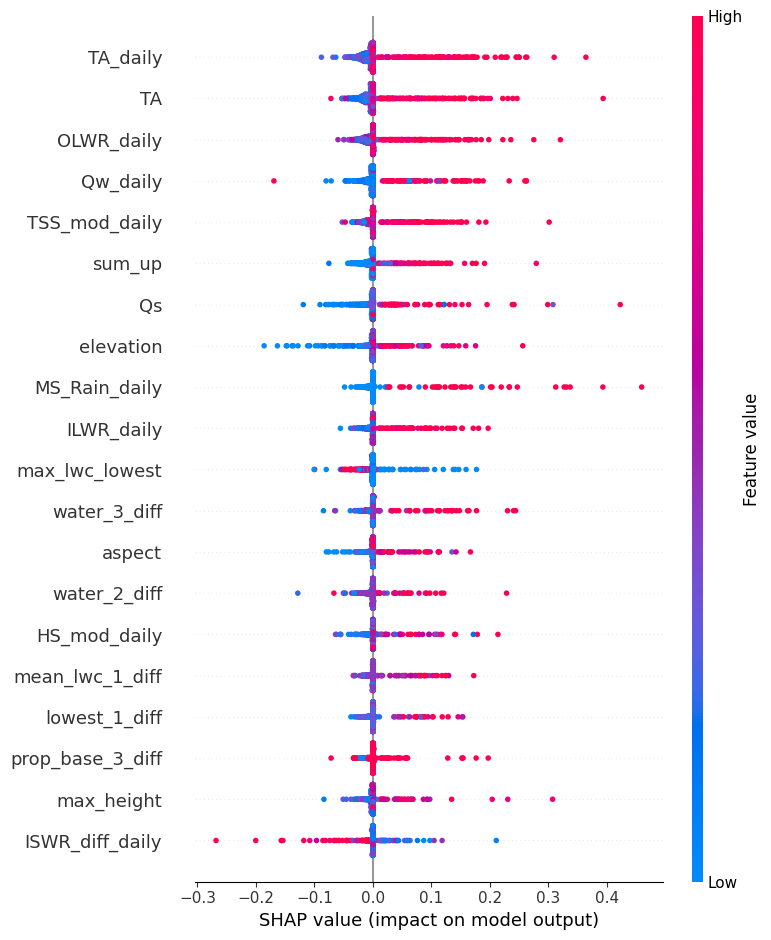

In [38]:
#shap needs a func. that takes np.arrays and returns outputs (ideally prob.)
#Use here the sigmoid output
def predict_fn(x_numpy):
    x_tensor = torch.tensor(x_numpy, dtype=torch.float32)
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.sigmoid(logits)
    return probs.numpy()

#NOW use: SHAP's KernelExplainer (preferred for custom models)
explainer = shap.KernelExplainer(predict_fn, X_background)
shap_values = explainer.shap_values(X_explain, nsamples= 100)  # auto is reccomended?

#inverse transform features
X_test_original = scaler.inverse_transform(X_explain)

#squezze the last dimesnion
shap_values_single = shap_values.squeeze(-1)  # from (2059, 84, 1) to (2059, 84)

#Visualize
shap.summary_plot(shap_values_single, X_test_original, feature_names=X.columns)